In [1]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")


In [2]:
# Create output directories if they don't exist
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)


In [3]:
# Locate and load all CICIDS2017 CSV files
raw_data_path = "../data/raw/MachineLearningCVE/"
files = [f for f in os.listdir(raw_data_path) if f.endswith('.csv')]

print(f"Found {len(files)} files to process:")
for f in files:
    print(f" • {f}")

# Combine into a single massive dataframe
dfs = []
for f in files:
    df = pd.read_csv(os.path.join(raw_data_path, f))
    dfs.append(df)
    
raw_df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal Raw Rows Loaded: {len(raw_df)}")

Found 8 files to process:
 • Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 • Monday-WorkingHours.pcap_ISCX.csv
 • Friday-WorkingHours-Morning.pcap_ISCX.csv
 • Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 • Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 • Tuesday-WorkingHours.pcap_ISCX.csv
 • Wednesday-workingHours.pcap_ISCX.csv
 • Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Total Raw Rows Loaded: 2830743


In [4]:
# Select features
selected_features = [
    ' Flow Duration', 
    ' Total Fwd Packets', 
    ' Total Backward Packets',
    ' Total Length of Fwd Packets', 
    ' Total Length of Bwd Packets',
    ' Flow Bytes/s', 
    ' Flow Packets/s', 
    ' FIN Flag Count',
    ' SYN Flag Count', 
    ' ACK Flag Count', 
    ' Packet Length Mean',
    ' Fwd Packet Length Mean', 
    ' Bwd Packet Length Mean',
    ' Fwd Packet Length Max', 
    ' Bwd Packet Length Min',
    ' Down/Up Ratio', 
    ' Flow IAT Mean', 
    ' Flow IAT Std',
    ' Active Mean', 
    ' Idle Mean', 
    ' Subflow Fwd Bytes'
]

# Clean column names (strip whitespace)
selected_features = [col.strip() for col in selected_features]
raw_df.columns = raw_df.columns.str.strip()

df = raw_df[selected_features + ['Label']].copy()

# Data Sanitation: Replace Infinity with NaN, then fill NaNs with 0
print("Sanitizing Data...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print("Null values remaining:", df.isnull().sum().sum())
print("Infinity values remaining:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Sanitizing Data...
Null values remaining: 0
Infinity values remaining: 0


In [5]:
print("--- Class Distribution ---")
print(df['Label'].value_counts())

# Isolate Normal vs Attack traffic
normal_df = df[df['Label'] == 'BENIGN']
attack_df = df[df['Label'] != 'BENIGN']

print(f"\nTotal Normal Flows: {len(normal_df)}")
print(f"Total Attack Flows: {len(attack_df)}")

# Create Training Set: 80% of Benign Data ONLY
X_train_benign, X_test_benign = train_test_split(normal_df, test_size=0.2, random_state=42)

# Create Testing Set: Remaining 20% Benign + 100% of Attack Data
test_mixed = pd.concat([X_test_benign, attack_df])

# Drop Labels from Training Set 
X_train = X_train_benign.drop('Label', axis=1)

# Separate features and labels for Evaluation Set
y_test = test_mixed['Label']
X_test = test_mixed.drop('Label', axis=1)

print(f"\nFinal Training Shape (Benign Only): {X_train.shape}")
print(f"Final Testing Shape (Mixed Traffic): {X_test.shape}")

--- Class Distribution ---
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total Normal Flows: 2273097
Total Attack Flows: 557646

Final Training Shape (Benign Only): (1818477, 21)
Final Testing Shape (Mixed Traffic): (1012266, 21)


In [6]:

print("Sanitizing data and applying Log-Transformation + MinMaxScaler...")

# Clip physically impossible negative values (like negative flow duration) to 0
X_train_clipped = np.clip(X_train, a_min=0, a_max=None)
X_test_clipped = np.clip(X_test, a_min=0, a_max=None)

# Log Transformation 
X_train_log = np.log1p(X_train_clipped)
X_test_log = np.log1p(X_test_clipped)

# Strict scaling between 0 and 1
scaler = MinMaxScaler()

# Fit ONLY on the log-transformed training data
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

print("Data Scaling Complete. No Infinities or NaNs remaining!")

Sanitizing data and applying Log-Transformation + MinMaxScaler...
Data Scaling Complete. No Infinities or NaNs remaining!


In [7]:
print("Exporting processed arrays and scaler model...")

# Save Training Data
np.save("../data/processed/X_train.npy", X_train_scaled)

# Save Testing Data
np.save("../data/processed/X_test.npy", X_test_scaled)

# Save Labels 
np.save("../data/processed/y_test.npy", y_test.to_numpy())

# Save the fitted scaler so the Live Client can use it on PCAP data
joblib.dump(scaler, "../models/scaler.pkl")

print("Export Complete. Ready for Model Training.")

Exporting processed arrays and scaler model...
Export Complete. Ready for Model Training.


## VISUALIZATION

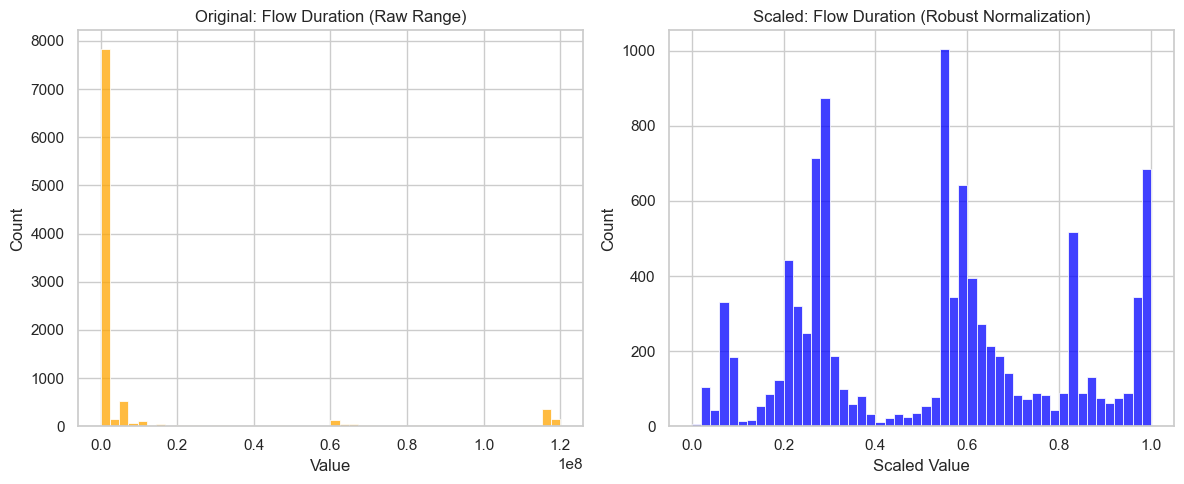

In [8]:
# 1. Feature Scaling Visualization (Before vs After)
feature_index = 0 
feature_name = selected_features[feature_index]

plt.figure(figsize=(12, 5))

# Original Data
plt.subplot(1, 2, 1)
sns.histplot(X_train[feature_name].iloc[:10000], bins=50, color='orange')
plt.title(f"Original: {feature_name} (Raw Range)")
plt.xlabel('Value')

# Robust Scaled Data
plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled[:10000, feature_index], bins=50, color='blue')
plt.title(f"Scaled: {feature_name} (Robust Normalization)")
plt.xlabel('Scaled Value')

plt.tight_layout()
plt.show()



/Users/sujannainawasti/miniconda3/envs/fl_project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


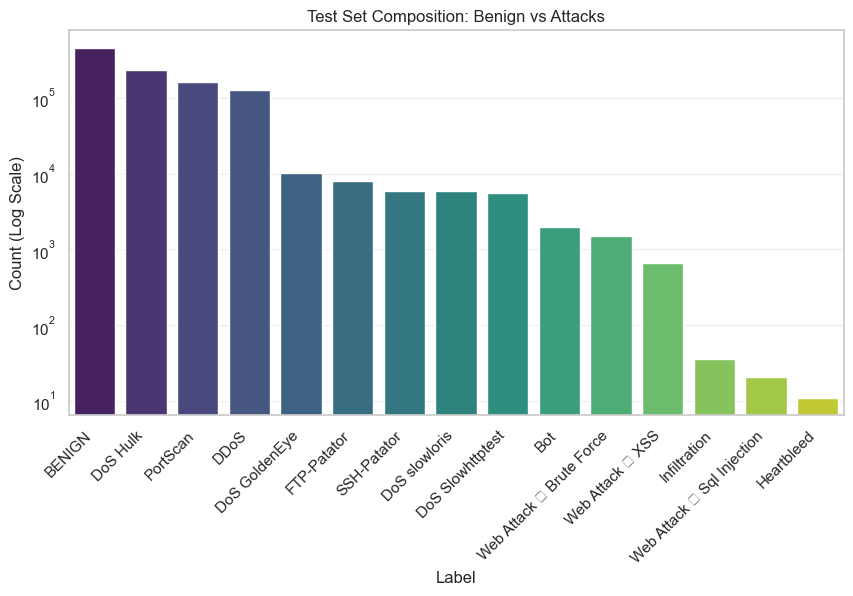

In [9]:
# 2. Test Set Attack Distribution
plt.figure(figsize=(10, 5))
count_data = y_test.value_counts()
sns.barplot(x=count_data.index, y=count_data.values, hue=count_data.index, palette="viridis", legend=False)
plt.title("Test Set Composition: Benign vs Attacks")
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()